In [ ]:
# Swap in an Ornstein–Uhlenbeck (OU / exponential) kernel and re-run the demo
# k(x, x') = variance * exp(-|x - x'| / length_scale)
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### task variable dependent OU process

In [ ]:
rng = np.random.default_rng(123)

def ou_kernel(xa, xb, length_scale=0.25, variance=1.0):
    xa = np.atleast_2d(xa).reshape(-1, 1)  # (n_a, 1)
    xb = np.atleast_2d(xb).reshape(1, -1)  # (1, n_b)
    d = np.abs(xa - xb)                    # pairwise distances
    return variance * np.exp(-d / length_scale)

def gp_prior_sample(X, n_samples=5, kernel=ou_kernel, **kargs):
    K = kernel(X, X, **kargs)
    K = K + 1e-9*np.eye(len(X))
    L = np.linalg.cholesky(K)
    z = rng.standard_normal((len(X), n_samples))
    return (L @ z).T


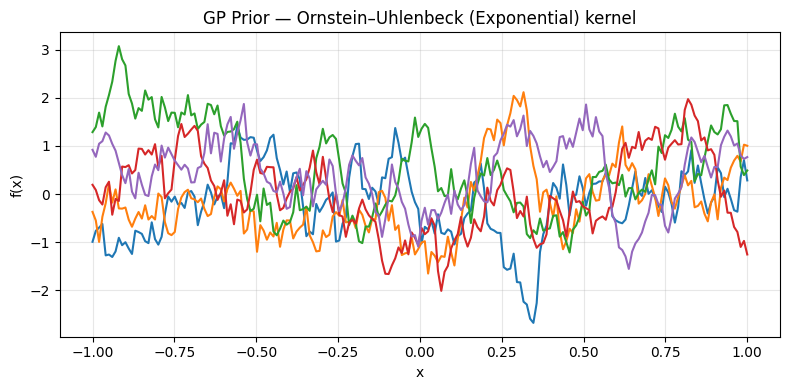

In [3]:
# Parameters
X_plot = np.linspace(-1.0, 1.0, 200)
ell = 0.2         # OU length-scale
var = 1.0
noise_std = 0.05

# 1) Prior samples (OU)
prior_samples = gp_prior_sample(X_plot, n_samples=5, kernel=ou_kernel, length_scale=ell, variance=var)
plt.figure(figsize=(8, 4))
for f in prior_samples:
    plt.plot(X_plot, f, lw=1.5)
plt.title("GP Prior — Ornstein–Uhlenbeck (Exponential) kernel")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### time dependent OU process

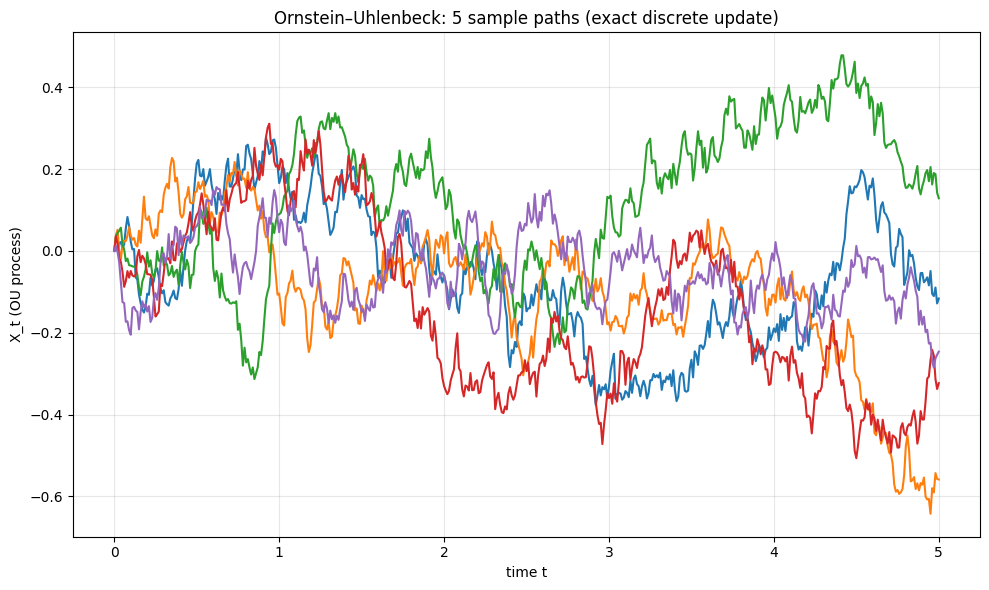

In [ ]:
# Ornstein–Uhlenbeck (OU) toy demo: 5 sample paths
# We'll use the exact discrete-time update for numerical stability.
# OU parameters (feel free to tweak later)
theta = 1.0   # mean-reversion rate
mu = 0.0      # long-run mean
sigma = 0.3   # diffusion scale
x0 = 0.0      # initial value

T = 5.0       # total time
N = 500       # number of steps
dt = T / N
t = np.linspace(0, T, N + 1)

num_paths = 5

# Precompute constants for exact transition
exp_term = np.exp(-theta * dt)
mean_factor = (1 - exp_term)
var_factor = (1 - np.exp(-2 * theta * dt)) / (2 * theta)
std_incr = sigma * np.sqrt(var_factor)

paths = np.zeros((N + 1, num_paths))
paths[0, :] = x0

rng = np.random.default_rng(0)

for j in range(num_paths):
    x = x0
    for i in range(1, N + 1):
        # Exact discrete update: X_{t+dt} | X_t ~ Normal(m, s^2)
        mean_next = x * exp_term + mu * mean_factor
        x = mean_next + std_incr * rng.standard_normal()
        paths[i, j] = x

# Plot the 5 sample paths
plt.figure(figsize=(10, 6))
for j in range(num_paths):
    plt.plot(t, paths[:, j], linewidth=1.5)
plt.xlabel("time t")
plt.ylabel("X_t (OU process)")
plt.title("Ornstein–Uhlenbeck: 5 sample paths (exact discrete update)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show the data in a small table (first 10 rows) and provide full DF to user
df = pd.DataFrame(paths, columns=[f"path_{j+1}" for j in range(num_paths)])
df.insert(0, "t", t)
